
# Lab 7: Fast Fourier Transform (FFT)

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)



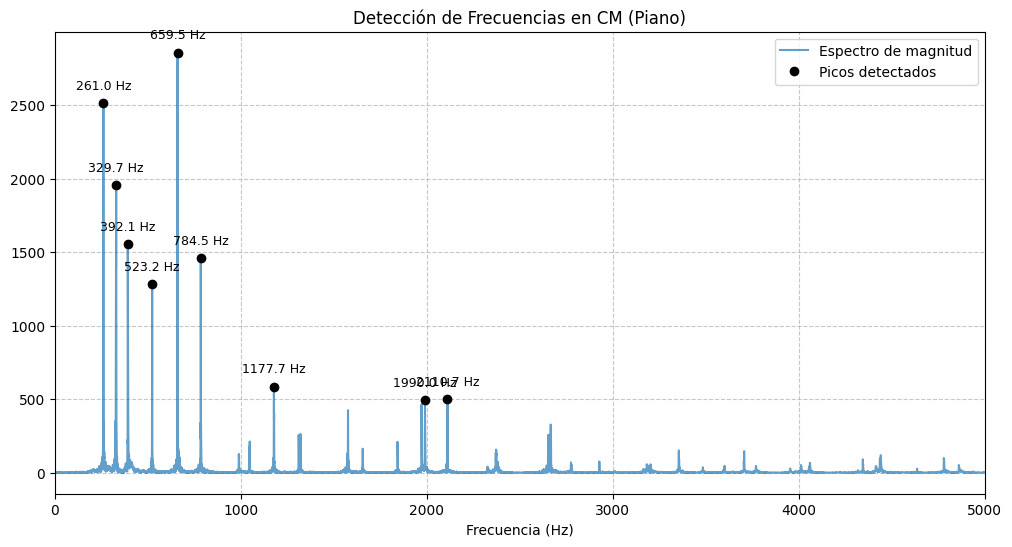

In [3]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import interpolate, integrate
import pandas as pd

# 1. Cargar audio
signal, sr = librosa.load(r"Nota_CM_piano.mp3", sr=None)

# 2. Calcular FFT real
N = len(signal)
tf_magnitude = np.abs(np.fft.rfft(signal))
frecuencias = np.fft.rfftfreq(N, d=1/sr)

# 3. Detectar picos
# 'height' define la intensidad mínima (ej. 0.1 del máximo)
# 'distance' evita detectar múltiples puntos en un mismo pico ancho
peaks, properties = find_peaks(tf_magnitude, height=470, distance=20)

plt.figure(figsize=(12, 6))
plt.plot(frecuencias, tf_magnitude, label="Espectro de magnitud", alpha=0.7)
plt.plot(frecuencias[peaks], tf_magnitude[peaks], "ko", label="Picos detectados") 

for i, peak_idx in enumerate(peaks):
    freq = frecuencias[peak_idx]
    plt.annotate(f"{freq:.1f} Hz", 
                 (freq, tf_magnitude[peak_idx]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9,
)

plt.title("Detección de Frecuencias en CM (Piano)")
plt.xlabel("Frecuencia (Hz)")
plt.xlim(0, 5000)  # Rango audible principal del piano
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


El resultado se confirma directamente a través de los picos observados en el espectro de magnitud. La presencia del acorde se valida al identificar las frecuencias fundamentales (los primeros picos de cada serie armónica) que componen la tríada:261.0 Hz: Tónica. Corresponde a la nota fundamental Do ($C_4$).329.7 Hz: Tercera mayor. Corresponde a la nota fundamental Mi ($E_4$).392.1 Hz: Quinta justa. Corresponde a la nota fundamental Sol ($G_4$).La detección concurrente de estas tres frecuencias fundamentales establece que el audio contiene un acorde de Do Mayor (CM). Los picos subsecuentes en el gráfico son armónicos de estas tres notas.

2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?

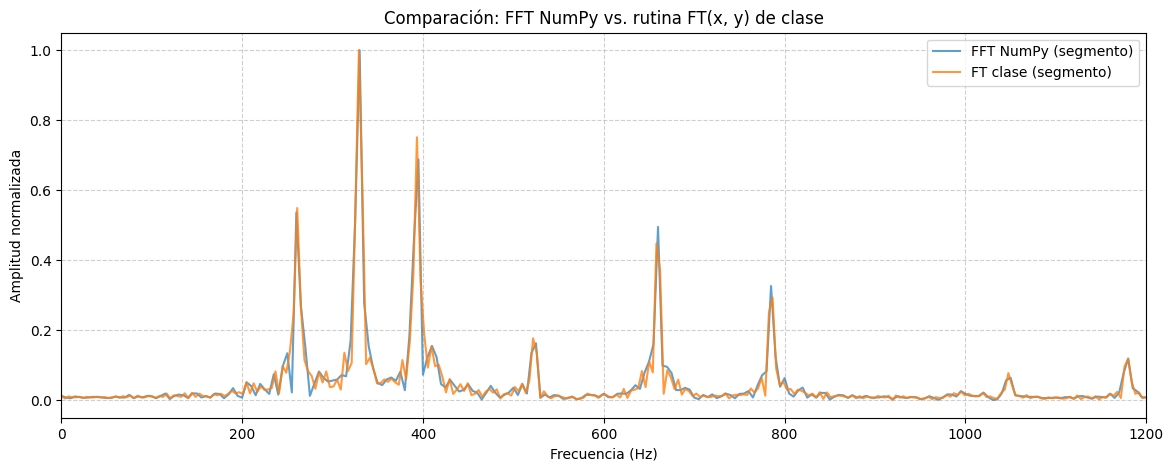

Top frecuencias FFT NumPy (Hz): [330. 395. 260. 325. 660. 390.]
Top frecuencias FT clase (Hz): [329.2 393.4 333.2 260.9 325.2 658.2]


In [8]:
def g(t, w):
    return 1.0 / (2 * np.pi) * np.exp(-1j * 2 * np.pi * w * t)

def FT(x, y, w_min=0.1, w_max=1200, n_w=300, n_int=2000):
    """Calcula la transformada de Fourier continua aproximada de f(t) usando cuadratura discreta."""
    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    t_int = np.linspace(x.min(), x.max(), n_int)
    f_vals = f_interp(t_int)
    w = np.linspace(w_min, w_max, n_w)
    df = []
    dt = np.diff(t_int)
    
    for wi in w:
        z = f_vals * g(t_int, wi)
        integral = np.sum((z[:-1] + z[1:]) * 0.5 * dt)
        ARew = np.real(integral)
        AImw = np.imag(integral)
        AMP = np.abs(integral)
        df.append([wi, ARew, AImw, AMP])
    return pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP'])

segment_time = 0.2 # segundos
segment_samples = int(segment_time * sr)
x_segment = np.arange(segment_samples) / sr
y_segment = signal[:segment_samples]

df_ft = FT(x_segment, y_segment, w_min=0.1, w_max=1200, n_w=300, n_int=2000)

Nseg = len(y_segment)
yf_seg = np.abs(np.fft.rfft(y_segment))
freqs_fft = np.fft.rfftfreq(Nseg, d=1 / sr)

np_fft_norm = yf_seg / np.max(yf_seg)
ft_norm = df_ft.AMP / np.max(df_ft.AMP)

plt.figure(figsize=(14, 5))
plt.plot(freqs_fft, np_fft_norm, label='FFT NumPy (segmento)', alpha=0.7)
plt.plot(df_ft.w, ft_norm, label='FT clase (segmento)', alpha=0.8)
plt.xlim(0, 1200)
plt.title('Comparación: FFT NumPy vs. rutina FT(x, y) de clase')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud normalizada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

idx_fft = np.argsort(np_fft_norm)[-6:][::-1]
idx_ft = np.argsort(ft_norm)[-6:][::-1]
print('Top frecuencias FFT NumPy (Hz):', np.round(freqs_fft[idx_fft], 1))
print('Top frecuencias FT clase (Hz):', np.round(df_ft.w.iloc[idx_ft].values, 1))

NOTA 5.0. MUY BIEN. 